### Perform all the following tasks on the above dataset.

1. Dataset Acquisition: Download Heart Failure Clinical Records Dataset
2. Load Dataset: Read dataset as pandas DataFrame, display first 5 rows.
3. Summarize Dataset: Report number of rows, columns, data types, missing values.
4. Visualize Missing Values: Create heatmap using seaborn to show missing values.
5. Plot Distributions: Generate histograms or boxplots for numerical features (e.g., age,
ejection_fraction).
6. Impute Missing Values:
• Numerical features: Use mean or median (e.g., serum_creatinine).
• Categorical features: Use mode or "Unknown" (e.g., smoking).
7. Remove Outliers
8. Correct Inconsistencies: Check and fix invalid entries (e.g., negative age).
9. Feature Engineering:
• Create age_group feature (bins: <40, 40–60, >60).
• Create risk_score feature (e.g., normalized product of ejection_fraction,
serum_creatinine).
10. Encode Categorical Variables: Apply one-hot or label encoding to categorical features (e.g.,
sex, smoking).
11. Normalize Features: Scale numerical features (e.g., age, platelets) to 0–1 using MinMaxScaler.
12. Compute Summary Statistics: Calculate mean, median, standard deviation before and after
cleaning.
13. Validate Cleaning: Plot histograms or boxplots for cleaned numerical features.
14. Check Missing Values: Confirm no missing values remain or justify any remaining.

In [1]:
#imports
import pandas as pd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
from sklearn.preprocessing import MinMaxScaler

1. Dataset Acquisition: Download Heart Failure Clinical Records Dataset

In [3]:
print("Dataset downloaded successfully as \"heart_failure_clinical_records_dataset.csv\".")

Dataset downloaded successfully as "heart_failure_clinical_records_dataset.csv".


2. Load Dataset: Read dataset as pandas DataFrame, display first 5 rows.

In [4]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0.0,20.0,1,265000.00,1.9,130.0,1,0.0,4,1
1,55.0,0,7861,0.0,38.0,0,263358.03,1.1,136.0,1,0.0,6,1
2,65.0,0,146,0.0,20.0,0,162000.00,1.3,129.0,1,1.0,7,1
3,50.0,1,111,0.0,20.0,0,210000.00,1.9,137.0,1,0.0,7,1
4,65.0,1,160,1.0,20.0,0,327000.00,2.7,116.0,0,0.0,8,1


3. Summarize Dataset: Report number of rows, columns, data types, missing values.

In [5]:
print("Number of rows and columns:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows and columns: (299, 13)

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                    float64
ejection_fraction           float64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                float64
sex                           int64
smoking                     float64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    1
ejection_fraction           1
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                2
sex                         0
smoking                     1
time                        0
DEATH_EVENT                 0
dtype: int64


4. Visualize Missing Values: Create heatmap using seaborn to show missing values.

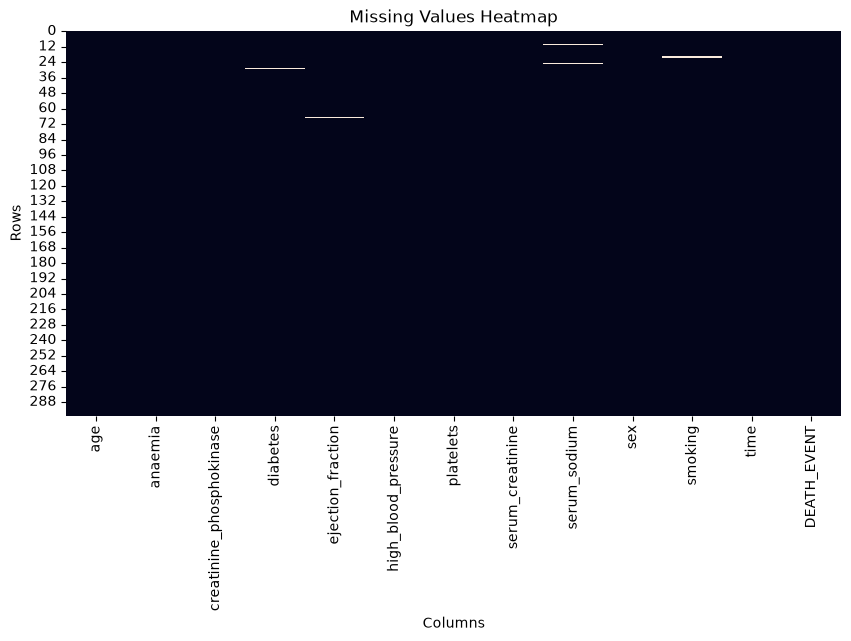

In [6]:
# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

5. Plot Distributions: Generate histograms or boxplots for numerical features (e.g., age,
ejection_fraction).

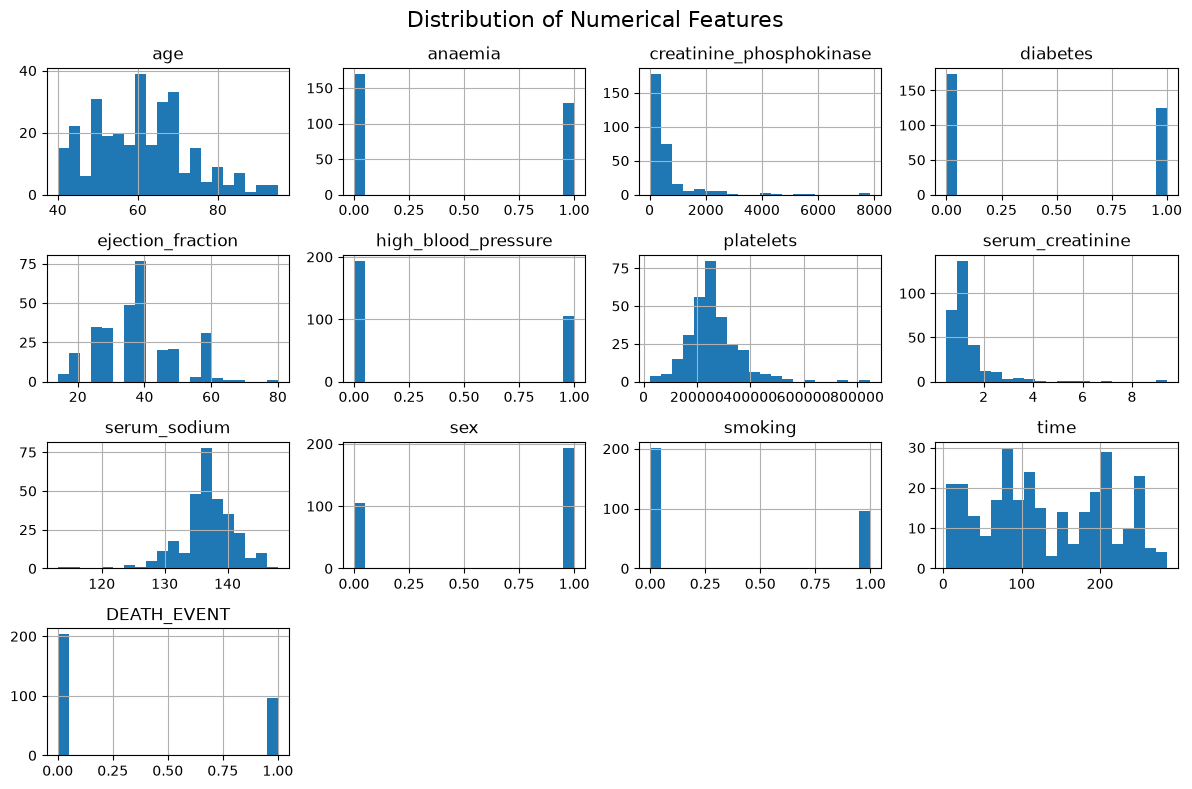

In [ ]:
# import matplotlib.pyplot as plt

df.hist(figsize=(12, 8), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

6. Impute Missing Values:

• Numerical features: Use mean or median (e.g., serum_creatinine).

• Categorical features: Use mode or "Unknown" (e.g., smoking).


In [9]:
# Numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


7. Remove Outliers

In [10]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[
    ~((df[numerical_columns] < lower_bound) |
      (df[numerical_columns] > upper_bound)).any(axis=1)
]

print("Original number of rows:", len(df))
print("Number of rows after removing outliers:", len(df_cleaned))
print("Number of outliers removed:", len(df) - len(df_cleaned))

Original number of rows: 299
Number of rows after removing outliers: 224
Number of outliers removed: 75


8. Correct Inconsistencies: Check and fix invalid entries (e.g., negative age).


In [12]:
print(df[df['age'] < 0])

Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


9. Feature Engineering:

• Create age_group feature (bins: <40, 40–60, >60).

• Create risk_score feature (e.g., normalized product of ejection_fraction,
serum_creatinine).

In [13]:
# Create age_group feature
df_cleaned["age_group"] = pd.cut(
    df_cleaned["age"],
    bins=[0, 40, 60, float("inf")],
    labels=["<40", "40-60", ">60"],
    right=False
)

# Create risk_score
risk_score = (
    df_cleaned["ejection_fraction"] *
    df_cleaned["serum_creatinine"]
)

df_cleaned["risk_score"] = (
    (risk_score - risk_score.min()) /
    (risk_score.max() - risk_score.min())
)

# Display the new features
df_cleaned[["age", "age_group", "ejection_fraction",
            "serum_creatinine", "risk_score"]].head()

,age,age_group,ejection_fraction,serum_creatinine,risk_score
0,75.0,>60,20.0,1.9,0.310545
2,65.0,>60,20.0,1.3,0.171495
3,50.0,40-60,20.0,1.9,0.310545
5,90.0,>60,40.0,2.1,0.843569
6,75.0,>60,15.0,1.2,0.078795


10. Encode Categorical Variables: Apply one-hot or label encoding to categorical features (e.g.,
sex, smoking).

In [14]:
# Check categorical columns

categorical_columns = df_cleaned.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['age_group']


In [15]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=["age_group"],
    drop_first=True,
    dtype=int
)

print("Categorical variable encoded successfully.")

print("\nNew columns:")
print(df_cleaned.columns)

Categorical variable encoded successfully.

New columns:
Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT', 'risk_score', 'age_group_40-60', 'age_group_>60'],
      dtype='str')


11. Normalize Features: Scale numerical features (e.g., age, platelets) to 0–1 using MinMaxScaler.

In [17]:
# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical_columns = df_cleaned.select_dtypes(
    include=["int64", "float64"]
).columns

df_cleaned[numerical_columns] = scaler.fit_transform(
    df_cleaned[numerical_columns]
)

print("Numerical features normalized successfully.")

print("\nFirst 5 rows after normalization:")
print(df_cleaned.head())

Numerical features normalized successfully.

First 5 rows after normalization:
        age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  0.636364      0.0                  0.470990       0.0           0.117647   
2  0.454545      0.0                  0.098976       0.0           0.117647   
3  0.181818      1.0                  0.069113       0.0           0.117647   
5  0.909091      1.0                  0.014505       0.0           0.509804   
6  0.636364      1.0                  0.184300       0.0           0.019608   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                  1.0   0.468852          0.866667      0.217391  1.0   
2                  0.0   0.131148          0.466667      0.173913  1.0   
3                  0.0   0.288525          0.866667      0.521739  1.0   
5                  1.0   0.268852          1.000000      0.304348  1.0   
6                  0.0   0.016393          0.400000      0.521739  1.0   

 

12. Compute Summary Statistics: Calculate mean, median, standard deviation before and after
cleaning.

In [18]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

# Statistics before cleaning
before_cleaning = df[numerical_columns].agg(
    ["mean", "median", "std"]
)

# Statistics after cleaning
after_cleaning = df_cleaned[numerical_columns].agg(
    ["mean", "median", "std"]
)

print("Statistics Before Cleaning:")
print(before_cleaning)

print("\nStatistics After Cleaning:")
print(after_cleaning)

Statistics Before Cleaning:
              age   anaemia  creatinine_phosphokinase  diabetes  \
mean    60.833893  0.431438                581.839465  0.414716   
median  60.000000  0.000000                250.000000  0.000000   
std     11.894809  0.496107                970.287881  0.493499   

        ejection_fraction  high_blood_pressure      platelets  \
mean            38.127090             0.351171  263358.029264   
median          38.000000             0.000000  262000.000000   
std             11.810468             0.478136   97804.236869   

        serum_creatinine  serum_sodium       sex  smoking        time  \
mean             1.39388    136.622074  0.648829  0.32107  130.260870   
median           1.10000    137.000000  1.000000  0.00000  115.000000   
std              1.03451      4.379748  0.478136  0.46767   77.614208   

        DEATH_EVENT  
mean        0.32107  
median      0.00000  
std         0.46767  

Statistics After Cleaning:
             age  anaemia  creati

13. Validate Cleaning: Plot histograms or boxplots for cleaned numerical features.


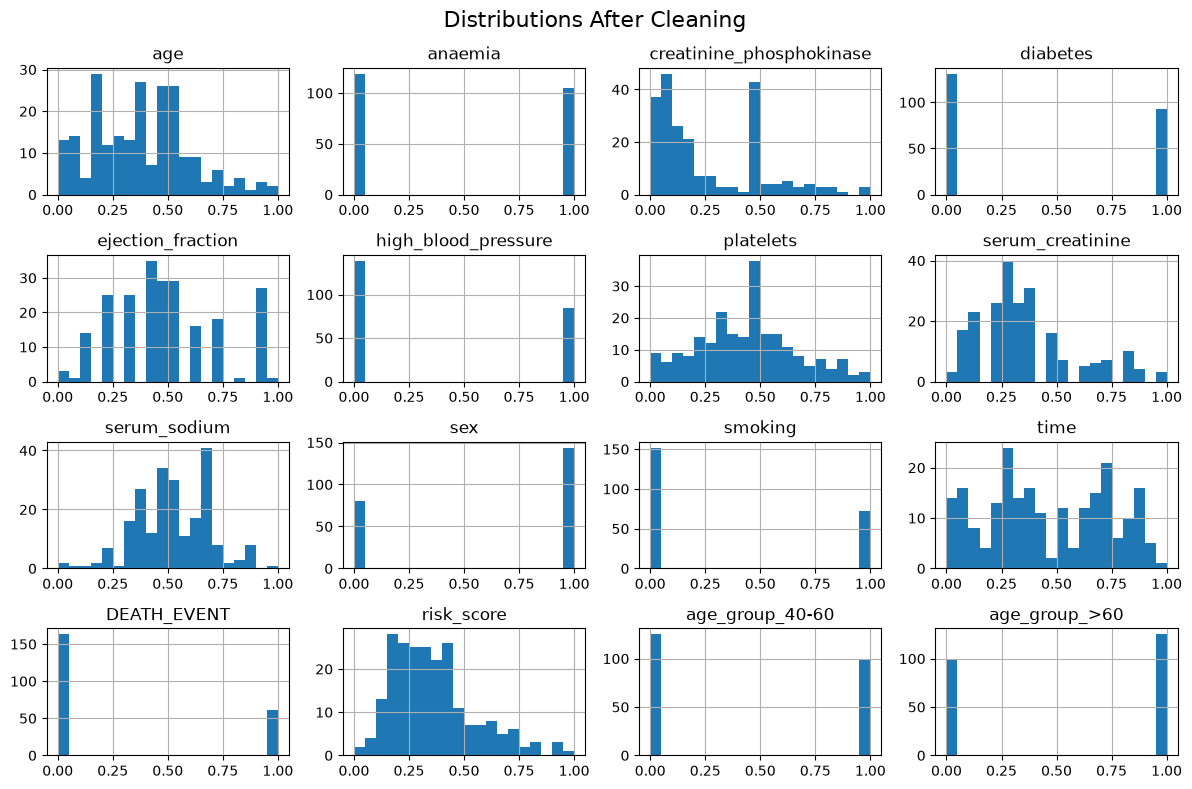

In [ ]:
# import matplotlib.pyplot as plt

# numerical_features = [
#     "age",
#     "ejection_fraction",
#     "serum_creatinine",
#     "platelets"
# ]

df_cleaned.hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle(
    "Distributions After Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

14. Check Missing Values: Confirm no missing values remain or justify any remaining.

In [21]:
missing_values = df_cleaned.isnull().sum()

print("Missing values after cleaning:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

if missing_values.sum() == 0:
    print("No missing values remain after cleaning.")
else:
    print("Some missing values still remain.")

Missing values after cleaning:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values: 0
No missing values remain after cleaning.
